导入包

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sklearn
import os
import sys
import time
from tqdm.auto import tqdm
import torch.nn.functional as F
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


cuda:0


导入数据 预处理

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
fpath = Path(r"./SONY_daily_data.csv")
df = pd.read_csv(fpath, encoding="utf-8")
df = df.iloc[9064:].reset_index(drop=True)
data = df[["Close", "Volume"]].values
seq_len = 30
split_time = int(len(data) * 0.8)
train_raw = data[:split_time]
test_raw = data[split_time:]
scaler = StandardScaler()
train_norm = scaler.fit_transform(train_raw)
test_norm = scaler.transform(test_raw)

Dataset

In [3]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len : i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
X_train, y_train = create_sequences(train_norm, seq_len)
test_input = np.concatenate([train_norm[-seq_len:], test_norm], axis=0)
X_test, y_test = create_sequences(test_input, seq_len)
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Dataloader

In [4]:
train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

测试

In [5]:
test1xiaX = torch.randn(500, 60, 2)
test1xiay = torch.randn(500, 1)
test1xia_train_loader = DataLoader(StockDataset(test1xiaX, test1xiay), batch_size=32, shuffle=True)
print("X 形状:", test1xiaX.shape)
print("数据集长度:", len(test1xia_train_loader.dataset))

X 形状: torch.Size([500, 60, 2])
数据集长度: 500


C:\Users\DELL\AppData\Local\Temp\ipykernel_9352\611391381.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)
C:\Users\DELL\AppData\Local\Temp\ipykernel_9352\611391381.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float32)


LSTM

In [6]:
class LSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, output_size=1, seq_len=30):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.seq_len = seq_len
        self.input_size = input_size
        self.output_size = output_size
        
        # LSTM层
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # 全连接层
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        输入x: [batch_size, seq_len, input_size]
        输出: [batch_size, seq_len, output_size]
        """
        batch_size = x.size(0)  # 从输入获取batch_size
        pred_list = []
        
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        hidden = (h0, c0)
        
        for i in range(self.seq_len):
            x_step = x[:, i:i+1, :]  # 教师强制
            lstm_out, hidden = self.lstm(x_step, hidden)
            pred = self.fc(lstm_out)
            pred_list.append(pred)
        
        # 拼接成张量返回
        return torch.cat(pred_list, dim=1)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            output = self(x)  # [batch_size, seq_len, 1]
            pred = output[:, -1, :]  # [batch_size, 1]
        return pred

封装好的类

In [7]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


training

In [8]:
# 均方差损失
criterion = nn.MSELoss()
@torch.no_grad()
def evaluate(model, criterion, loader, device):
    loss_list = []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)  # [B, 60, 1]
            pred_loss = pred[:, -1, :]
            loss = criterion(pred_loss.squeeze(), y)
            loss_list.append(loss.cpu().item())
    
    return np.mean(loss_list)


def train(model, train_loader, test_loader, criterion, optimizer, epochs, device, tensorboard_callback, eval_step=20):
    record_dict = {"train": [], "val": []}
    global_step = 1
    model.train()
    
    with tqdm(total=epochs * len(train_loader), desc="Training", mininterval=0.1) as pbar:
        for epoch in range(epochs):
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                
                optimizer.zero_grad()
                pred = model(X)  # [B, 60, 1]
                pred_loss = pred[:, -1, :]
          
                loss = criterion(pred_loss.squeeze(), y)
                loss.backward()

                # 记录梯度和权重直方图
                if global_step % eval_step == 0:
                    for name, param in model.named_parameters():
                        if param.grad is not None :
                            tensorboard_callback.writer.add_histogram(f"grad/{name}", param.grad, global_step)
                            tensorboard_callback.writer.add_histogram(f"weight/{name}", param.data, global_step)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 梯度裁剪
                optimizer.step()
                record_dict["train"].append({"loss": loss.item(), "step": global_step})

                val_loss = "-"
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluate(model, criterion, test_loader, device)
                    model.train()
                    record_dict["val"].append({"loss": val_loss, "step": global_step})
                    
                    current_lr = optimizer.param_groups[0]["lr"]
                    tensorboard_callback(step=global_step, loss=loss.item(), val_loss=val_loss, lr=current_lr)

                pbar.set_postfix(epoch=epoch+1, loss=f"{loss.item():.4f}", val_loss=val_loss if isinstance(val_loss, float) else "-", refresh=True)
                pbar.update(1)
                global_step += 1

    return record_dict


epochs = 50
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = LSTM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

if not os.path.exists("runs"):
    os.mkdir("runs")
exp_name = "lstm_predict"
tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")

record = train(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
    tensorboard_callback=tensorboard_callback,
    eval_step=20
)
print(record)

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

{'train': [{'loss': 2.5117287635803223, 'step': 1}, {'loss': 1.9868848323822021, 'step': 2}, {'loss': 1.6187137365341187, 'step': 3}, {'loss': 1.2140157222747803, 'step': 4}, {'loss': 0.7495690584182739, 'step': 5}, {'loss': 0.7793791890144348, 'step': 6}, {'loss': 0.37198349833488464, 'step': 7}, {'loss': 0.6013907194137573, 'step': 8}, {'loss': 0.9661933183670044, 'step': 9}, {'loss': 0.6248495578765869, 'step': 10}, {'loss': 0.3004021644592285, 'step': 11}, {'loss': 0.0818452313542366, 'step': 12}, {'loss': 0.14187847077846527, 'step': 13}, {'loss': 0.043109096586704254, 'step': 14}, {'loss': 0.0828791931271553, 'step': 15}, {'loss': 0.8960028886795044, 'step': 16}, {'loss': 2.099247455596924, 'step': 17}, {'loss': 1.1901359558105469, 'step': 18}, {'loss': 2.1101276874542236, 'step': 19}, {'loss': 3.874359607696533, 'step': 20}, {'loss': 1.3241125345230103, 'step': 21}, {'loss': 0.35667893290519714, 'step': 22}, {'loss': 0.10232971608638763, 'step': 23}, {'loss': 0.24209168553352356

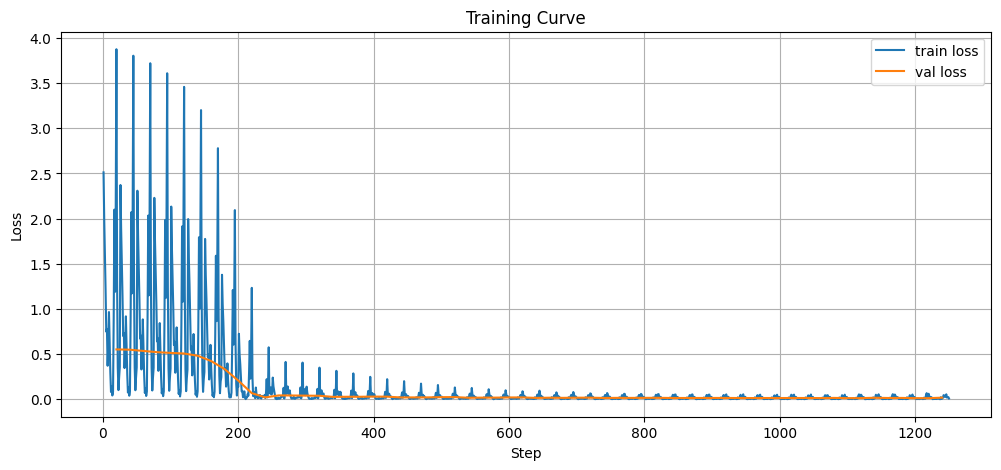

In [9]:
plt.figure(figsize=(12, 5))
plt.plot([i["step"] for i in record["train"]], [i["loss"] for i in record["train"]], label="train loss")
plt.plot([i["step"] for i in record["val"]], [i["loss"] for i in record["val"]], label="val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()

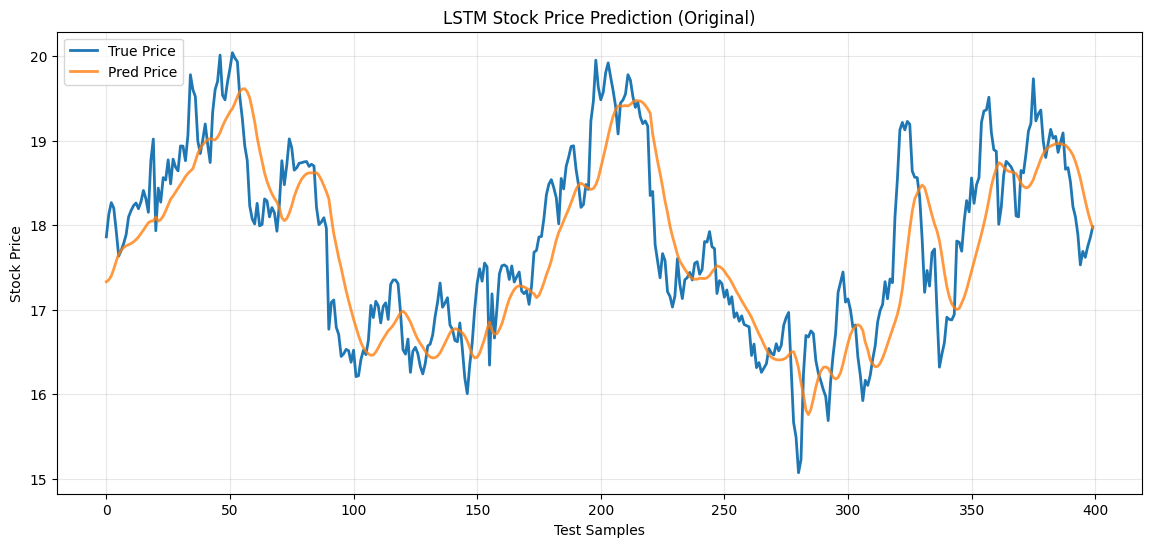

In [10]:
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams["axes.unicode_minus"] = False

model.eval()
pred_list = []
true_list = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X)[:, -1, :].squeeze()
        pred_list.append(pred.cpu().numpy())
        true_list.append(y.numpy())

predictions = np.concatenate(pred_list)
true_values = np.concatenate(true_list)


pred_2d = np.column_stack((predictions, np.zeros_like(predictions)))
true_2d = np.column_stack((true_values, np.zeros_like(true_values)))

# 逆标准化
pred_denorm = scaler.inverse_transform(pred_2d)
true_denorm = scaler.inverse_transform(true_2d)

# 只取第一列
predictions = pred_denorm[:, 0]
true_values = true_denorm[:, 0]

result_df = pd.DataFrame({
    "True_Close": true_values,
    "Pred_Close": predictions
})
result_df.to_csv("LSTM预测结果.csv", index=False, encoding="utf-8-sig")

# 绘图
plt.figure(figsize=(14, 6))
plt.plot(true_values, label="True Price", linewidth=2)
plt.plot(predictions, label="Pred Price", linewidth=2, alpha=0.8)
plt.title("LSTM Stock Price Prediction (Original)")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


cuda:0


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

{'train': [{'loss': 2.5874903202056885, 'step': 1}, {'loss': 2.037320375442505, 'step': 2}, {'loss': 1.694589376449585, 'step': 3}, {'loss': 1.2776706218719482, 'step': 4}, {'loss': 0.8023405075073242, 'step': 5}, {'loss': 0.8332048654556274, 'step': 6}, {'loss': 0.4032317101955414, 'step': 7}, {'loss': 0.6779434084892273, 'step': 8}, {'loss': 1.036736249923706, 'step': 9}, {'loss': 0.6607347726821899, 'step': 10}, {'loss': 0.3337072730064392, 'step': 11}, {'loss': 0.09213808178901672, 'step': 12}, {'loss': 0.1812029778957367, 'step': 13}, {'loss': 0.050002604722976685, 'step': 14}, {'loss': 0.06447090208530426, 'step': 15}, {'loss': 0.8460755348205566, 'step': 16}, {'loss': 1.9364237785339355, 'step': 17}, {'loss': 1.0631780624389648, 'step': 18}, {'loss': 1.9612762928009033, 'step': 19}, {'loss': 3.6278915405273438, 'step': 20}, {'loss': 1.1690239906311035, 'step': 21}, {'loss': 0.2972269058227539, 'step': 22}, {'loss': 0.09791609644889832, 'step': 23}, {'loss': 0.21401625871658325, 

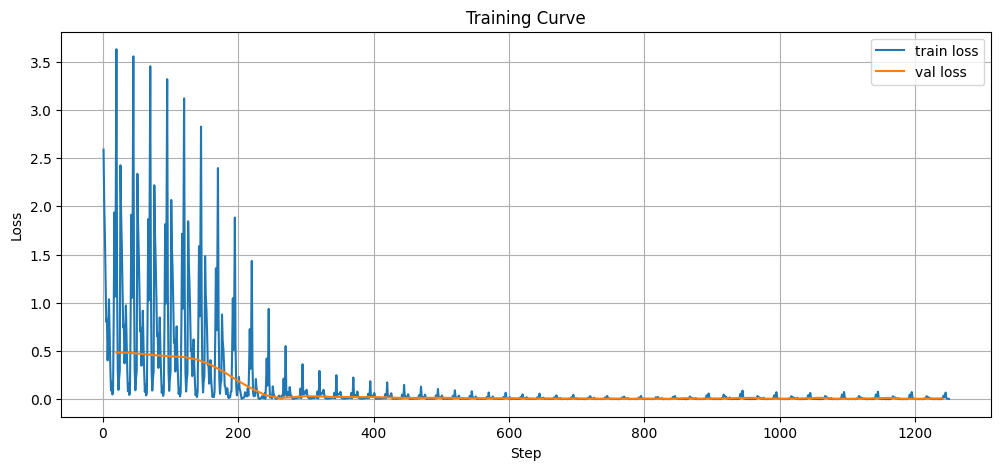

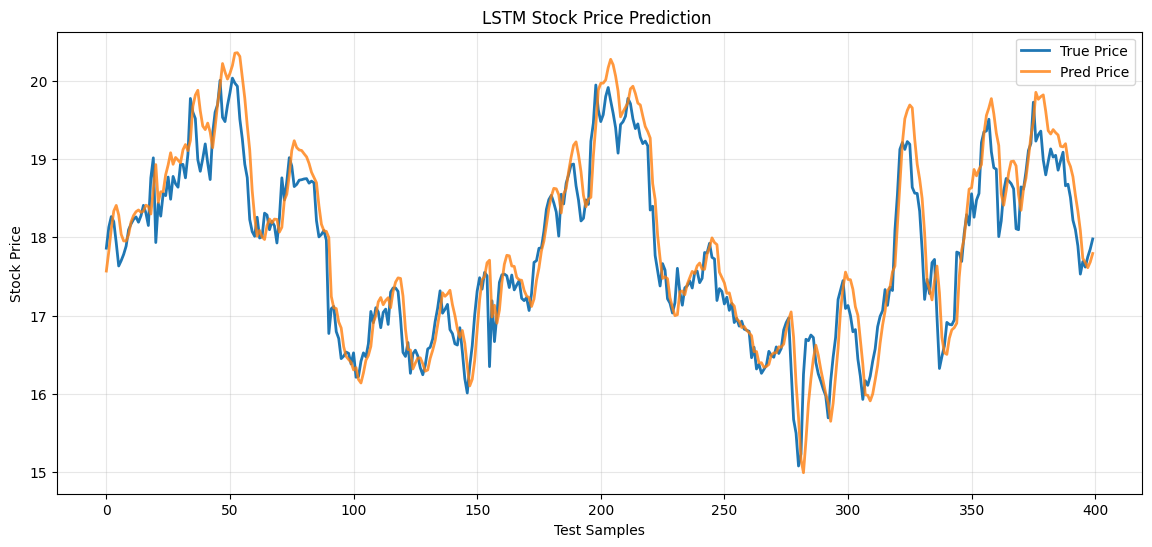

In [11]:
# 特征工程优化
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sklearn
import os
import sys
import time
from tqdm.auto import tqdm
import torch.nn.functional as F
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
fpath = Path(r"./SONY_daily_data.csv")
df = pd.read_csv(fpath, encoding="utf-8")
df['ma5'] = df['Close'].rolling(5).mean()
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['return'] = df['Close'].pct_change()
df['volatility_5'] = df['return'].rolling(5).std()
df["hl_range"] = df["High"] - df["Low"]
df = df.iloc[9064:].reset_index(drop=True)
data = df[["Close", "Volume", "rsi", "macd", "return", "volatility_5"]].values
seq_len = 30  
split_time = int(len(data) * 0.8)
train_raw = data[:split_time]  
test_raw  = data[split_time:] 
scaler = StandardScaler()
train_norm = scaler.fit_transform(train_raw)
test_norm  = scaler.transform(test_raw)

# 3. 构造序列函数
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len : i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
X_train, y_train = create_sequences(train_norm, seq_len)
test_input = np.concatenate([train_norm[-seq_len:], test_norm], axis=0)
X_test, y_test = create_sequences(test_input, seq_len)
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
class LSTM(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, output_size=1, seq_len=30):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.seq_len = seq_len
        self.input_size = input_size
        self.output_size = output_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        输入x: [batch_size, seq_len, input_size]
        输出: [batch_size, seq_len, output_size]
        """
        batch_size = x.size(0)  
        pred_list = []
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        hidden = (h0, c0)
        for i in range(self.seq_len):
            x_step = x[:, i:i+1, :]  # 教师强制
            lstm_out, hidden = self.lstm(x_step, hidden)
            pred = self.fc(lstm_out)
            pred_list.append(pred)
        
        # 拼接成张量返回
        return torch.cat(pred_list, dim=1)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            output = self(x)  # [batch_size, seq_len, 1]
            pred = output[:, -1, :]  # [batch_size, 1]
        return pred
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)
# 均方差损失
criterion = nn.MSELoss()
@torch.no_grad()
def evaluate(model, criterion, loader, device):
    loss_list = []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)  # [B, 60, 1]
            pred_loss = pred[:, -1, :]
            loss = criterion(pred_loss.squeeze(), y)
            loss_list.append(loss.cpu().item())
    
    return np.mean(loss_list)


def train(model, train_loader, test_loader, criterion, optimizer, epochs, device, tensorboard_callback, eval_step=20):
    record_dict = {"train": [], "val": []}
    global_step = 1
    model.train()
    
    with tqdm(total=epochs * len(train_loader), desc="Training", mininterval=0.1) as pbar:
        for epoch in range(epochs):
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)   
                optimizer.zero_grad()
                pred = model(X) 
                pred_loss = pred[:, -1, :]
                loss = criterion(pred_loss.squeeze(), y)
                loss.backward()
                if global_step % eval_step == 0:
                    for name, param in model.named_parameters():
                        if param.grad is not None :
                            tensorboard_callback.writer.add_histogram(f"grad/{name}", param.grad, global_step)
                            tensorboard_callback.writer.add_histogram(f"weight/{name}", param.data, global_step)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 梯度裁剪
                optimizer.step()
                record_dict["train"].append({"loss": loss.item(), "step": global_step})

                val_loss = "-"
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluate(model, criterion, test_loader, device)
                    model.train()
                    record_dict["val"].append({"loss": val_loss, "step": global_step})
                    
                    current_lr = optimizer.param_groups[0]["lr"]
                    tensorboard_callback(step=global_step, loss=loss.item(), val_loss=val_loss, lr=current_lr)

                pbar.set_postfix(epoch=epoch+1, loss=f"{loss.item():.4f}", val_loss=val_loss if isinstance(val_loss, float) else "-", refresh=True)
                pbar.update(1)
                global_step += 1

    return record_dict


epochs = 50
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = LSTM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

if not os.path.exists("runs"):
    os.mkdir("runs")
exp_name = "lstm_predict"
tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")

record = train(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
    tensorboard_callback=tensorboard_callback,
    eval_step=20
)
print(record)
plt.figure(figsize=(12, 5))
plt.plot([i["step"] for i in record["train"]], [i["loss"] for i in record["train"]], label="train loss")
plt.plot([i["step"] for i in record["val"]], [i["loss"] for i in record["val"]], label="val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams["axes.unicode_minus"] = False

model.eval()
pred_list = []
true_list = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X)[:, -1, :].squeeze()
        pred_list.append(pred.cpu().numpy())
        true_list.append(y.numpy())

predictions = np.concatenate(pred_list)
true_values = np.concatenate(true_list)
n_pred = len(predictions)
pred_2d = np.zeros((n_pred, 6))
pred_2d[:, 0] = predictions      

n_true = len(true_values)
true_2d = np.zeros((n_true, 6))
true_2d[:, 0] = true_values
pred_denorm = scaler.inverse_transform(pred_2d)
true_denorm = scaler.inverse_transform(true_2d)
predictions = pred_denorm[:, 0]
true_values = true_denorm[:, 0]
result_df = pd.DataFrame({
    "True_Close": true_values,
    "Pred_Close": predictions
})
result_df.to_csv("LSTM特征预测结果.csv", index=False, encoding="utf-8-sig")
plt.figure(figsize=(14, 6))
plt.plot(true_values, label="True Price", linewidth=2)
plt.plot(predictions, label="Pred Price", linewidth=2, alpha=0.8)
plt.title("LSTM Stock Price Prediction ")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()